# 🤖 Robot Prompt Embedding Visualization
**NLP Analysis — Outcome Category Clustering in Embedding Space**

This notebook:
1. Encodes robot prompts using **TF-IDF + Latent Semantic Analysis (LSA/SVD)**
2. Projects into 2-D with **PCA**, **t-SNE**, and **MDS**
3. Visualises how *success*, *failure*, and *partial* outcomes cluster
4. Saves all plots at **300 DPI**

> **Embedding strategy:** TF-IDF with both word (1-2g) and character (3-5g) n-grams is applied to the closed domain corpus (26 utterances). Character n-grams surface morphological similarity (e.g., *dance / danced / dancing*). Vectors are L2-normalised then compressed to 16-D via Truncated SVD (LSA) before projection.

## Imports & Global Aesthetics

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import random
import time
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.spatial import ConvexHull

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# ── Global style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'savefig.dpi'       : 300,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
})

# Perceptually distinct, colour-blind safe palette
PALETTE = {'success': '#2ecc71', 'failure': '#e74c3c', 'partial': '#f39c12'}
MARKERS  = {'success': 'o',      'failure': 'X',       'partial': 'D'}
SIZES    = {'success': 140,      'failure': 160,        'partial': 130}

SAVE_DIR = '.'   # change to your preferred output path
print('Environment ready ✓')

Environment ready ✓


## Dataset

In [2]:
rows = [
    (1, "can you spin",                      "success", "head moved / rotated"),
    (1, "can you rotate in a circle",         "success", "head rotated"),
    (1, "can you spin your head",             "failure", "could not do it"),
    (1, "can you jump",                       "failure", "no jump"),
    (1, "can you do a head dive",             "success", "it danced"),
    (1, "can you dance",                      "success", "moved head back and forth"),
    (1, "can you dance",                      "success", "moved head in circle"),
    (1, "can you dance",                      "success", "head bobble"),
    (1, "asked to dance",                     "success", "wiggled neck body"),
    (1, "asked to dance",                     "success", "shaked antenna"),
    (1, "asked to dance",                     "partial", "switched motion"),
    (2, "can you hop",                        "success", "rotated moved head"),
    (2, "can you jump",                       "failure", "no movement"),
    (2, "i cannot do that",                   "failure", "no movement"),
    (2, "i cannot do that",                   "failure", "no movement different voice"),
    (2, "sure i will dance",                  "success", "robot danced"),
    (2, "can you break dance",                "success", "sway and roll"),
    (2, "can you dance like a rock star",     "success", "nods its head"),
    (2, "can you dance like michael jackson", "success", "shifts side to side"),
    (3, "stand still then dance",             "partial", "did not stay still then danced"),
    (3, "explain quantum physics",            "failure", "refusal"),
    (3, "dance but stand still",              "partial", "robot stayed still"),
    (3, "be a cat and dance",                 "failure", "no action"),
    (3, "do the worm backflip",               "partial", "unexpected motion"),
    (3, "can you do a backflip",              "failure", "no motion"),
    (3, "can you do the whip nae nae",        "failure", "no motion"),
]

# NOTE: column named 'exp_round' to avoid conflict with pandas .round() method
df = pd.DataFrame(rows, columns=['exp_round', 'prompt', 'outcome', 'robot_response'])
df['prompt_id'] = range(len(df))

print(f"Dataset: {len(df)} prompts across {df['exp_round'].nunique()} rounds")
print(df.groupby('outcome').size().rename('count').to_frame())

Dataset: 26 prompts across 3 rounds
         count
outcome       
failure      9
partial      4
success     13


## Build Embeddings  (TF-IDF + LSA/SVD)

We use **character + word n-gram TF-IDF** to capture both lexical overlap and morphological
similarity, then compress to 16-D with Truncated SVD (Latent Semantic Analysis).
This gives dense vectors suitable for distance-based layouts.

In [3]:
# Step 1: TF-IDF — word n-grams (1,2) + character n-grams (3,5)
tfidf_word = TfidfVectorizer(analyzer='word',   ngram_range=(1, 2), min_df=1, sublinear_tf=True)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1, sublinear_tf=True)

X_word = tfidf_word.fit_transform(df['prompt']).toarray()
X_char = tfidf_char.fit_transform(df['prompt']).toarray()

# Concatenate & L2-normalise
X_raw  = np.hstack([X_word, X_char])
X_norm = normalize(X_raw, norm='l2')
print(f'TF-IDF feature matrix: {X_norm.shape}')

# Step 2: Compress to 16-D with LSA
n_components = min(16, X_norm.shape[0] - 1, X_norm.shape[1] - 1)
svd    = TruncatedSVD(n_components=n_components, random_state=42)
X_lsa  = svd.fit_transform(X_norm)
explained = svd.explained_variance_ratio_.sum()
print(f'LSA ({n_components}-D) explains {explained:.1%} of variance')

TF-IDF feature matrix: (26, 460)
LSA (16-D) explains 91.9% of variance


## Dimensionality Reduction — PCA, t-SNE, MDS

In [ ]:
random.seed(time.time())
# PCA
pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_lsa)
pca_var = pca.explained_variance_ratio_
print(f'PCA  PC1={pca_var[0]:.1%}  PC2={pca_var[1]:.1%}')

# t-SNE — perplexity ≤ n/3 for small corpora
perp   = min(7, len(df) // 3)
tsne   = TSNE(n_components=2, perplexity=perp, learning_rate='auto', init='pca',
              random_state=42, max_iter=2000)
X_tsne = tsne.fit_transform(X_lsa)
print(f't-SNE done  (perplexity={perp})')

# MDS — metric, cosine dissimilarity matrix
cos_dist = np.clip(1 - cosine_similarity(X_lsa), 0, None)
mds      = MDS(n_components=2, dissimilarity='precomputed',
               random_state=42, max_iter=1000, n_init=10)
X_mds    = mds.fit_transform(cos_dist)
print('MDS done')

df['pca_x'],  df['pca_y']  = X_pca[:, 0],  X_pca[:, 1]
df['tsne_x'], df['tsne_y'] = X_tsne[:, 0], X_tsne[:, 1]
df['mds_x'],  df['mds_y']  = X_mds[:, 0],  X_mds[:, 1]

PCA  PC1=14.9%  PC2=13.2%
t-SNE done  (perplexity=7)
MDS done


## Helper Functions

In [5]:
def draw_convex_hull(ax, x, y, color, alpha=0.13):
    """Draw a filled convex hull around a group of 2-D points."""
    pts = np.column_stack([x, y])
    if len(pts) < 3:
        return
    try:
        hull  = ConvexHull(pts)
        verts = np.append(hull.vertices, hull.vertices[0])
        ax.fill(pts[verts, 0], pts[verts, 1], color=color, alpha=alpha, zorder=0)
        ax.plot(pts[verts, 0], pts[verts, 1], color=color, lw=1.4, alpha=0.45, zorder=1)
    except Exception:
        pass


def scatter_outcomes(ax, df, xcol, ycol, title,
                     xlabel='Dim 1', ylabel='Dim 2',
                     annotate=True, hull=True):
    """Core scatter plot coloured by outcome with optional hulls & labels."""
    if hull:
        for outcome in ['success', 'failure', 'partial']:
            sub = df[df['outcome'] == outcome]
            draw_convex_hull(ax, sub[xcol], sub[ycol], PALETTE[outcome])

    for outcome in ['success', 'failure', 'partial']:
        sub = df[df['outcome'] == outcome]
        ax.scatter(sub[xcol], sub[ycol],
                   c=PALETTE[outcome], marker=MARKERS[outcome],
                   s=SIZES[outcome], edgecolors='white', linewidths=0.7,
                   label=outcome.capitalize(), zorder=3, alpha=0.9)

    if annotate:
        for _, row in df.iterrows():
            label = row['prompt'][:22] + ('…' if len(row['prompt']) > 22 else '')
            ax.annotate(label,
                        xy=(row[xcol], row[ycol]),
                        xytext=(4, 4), textcoords='offset points',
                        fontsize=5.5, alpha=0.75,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(fontsize=8, framealpha=0.8, edgecolor='#ccc',
              title='Outcome', title_fontsize=8)

print('Helpers defined ✓')

Helpers defined ✓


## Three-Panel Embedding Comparison (PCA · t-SNE · MDS)

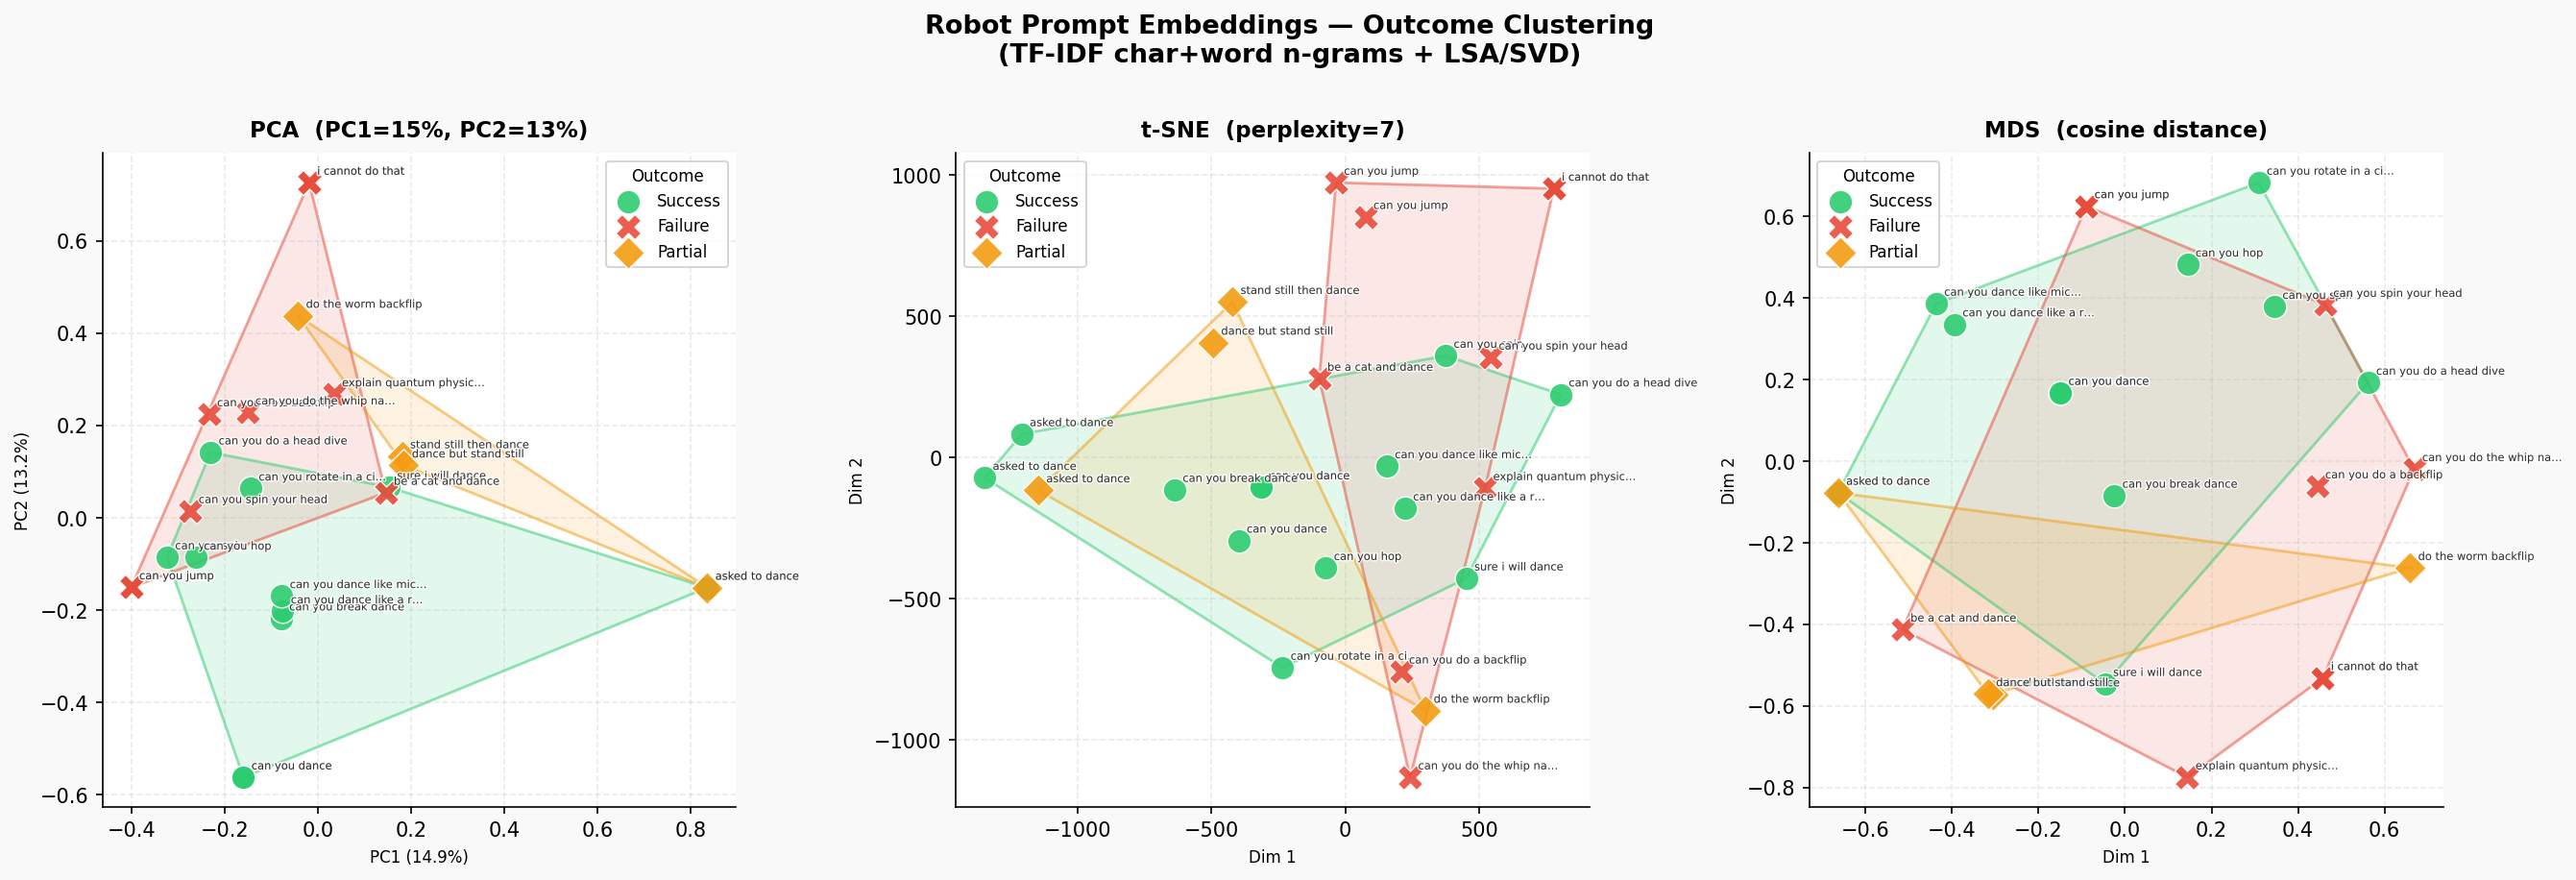

Saved → ./fig1_three_panel_comparison.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#f9f9f9')
fig.suptitle('Robot Prompt Embeddings — Outcome Clustering\n'
             '(TF-IDF char+word n-grams + LSA/SVD)',
             fontsize=13, fontweight='bold', y=1.01)

scatter_outcomes(axes[0], df, 'pca_x', 'pca_y',
                 f'PCA  (PC1={pca_var[0]:.0%}, PC2={pca_var[1]:.0%})',
                 xlabel=f'PC1 ({pca_var[0]:.1%})', ylabel=f'PC2 ({pca_var[1]:.1%})')
scatter_outcomes(axes[1], df, 'tsne_x', 'tsne_y',
                 f't-SNE  (perplexity={perp})')
scatter_outcomes(axes[2], df, 'mds_x', 'mds_y',
                 'MDS  (cosine distance)')

plt.tight_layout()
path1 = f'{SAVE_DIR}/fig1_three_panel_comparison.png'
plt.savefig(path1, dpi=300, bbox_inches='tight', facecolor='#f9f9f9')
plt.show()
print(f'Saved → {path1}')

## PCA Deep-Dive: Scatter + Scree Plot

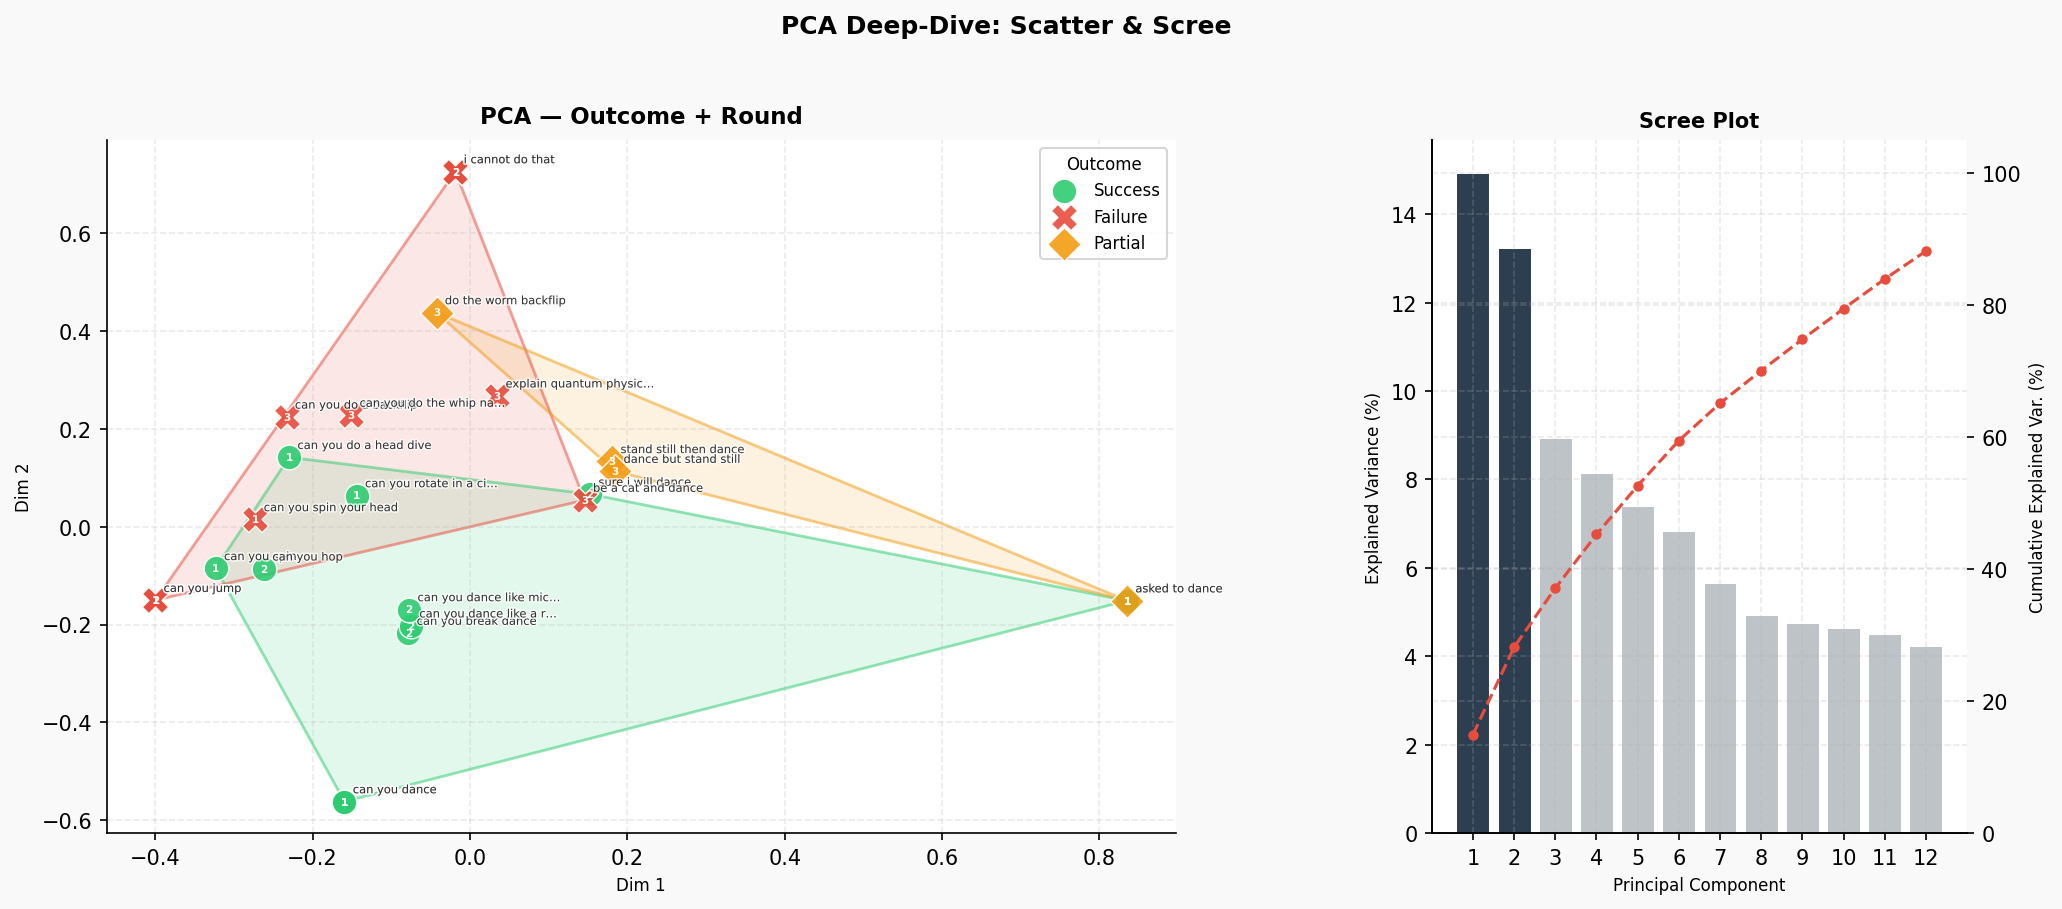

Saved → ./fig2_pca_deepdive.png


In [7]:
fig = plt.figure(figsize=(16, 6), facecolor='#f9f9f9')
gs  = GridSpec(1, 2, figure=fig, width_ratios=[2, 1], wspace=0.32)

# Left: PCA scatter with round number overlaid
ax0 = fig.add_subplot(gs[0])
scatter_outcomes(ax0, df, 'pca_x', 'pca_y', 'PCA — Outcome + Round', annotate=True, hull=True)
for _, row in df.iterrows():
    ax0.text(row['pca_x'], row['pca_y'], str(row['exp_round']),
             ha='center', va='center', fontsize=5, color='white',
             fontweight='bold', zorder=5)

# Right: Scree plot
ax1      = fig.add_subplot(gs[1])
pca_full = PCA(random_state=42).fit(X_lsa)
ev_ratio = pca_full.explained_variance_ratio_
cum_ev   = np.cumsum(ev_ratio)
n_show   = min(12, len(ev_ratio))

ax1.bar(range(1, n_show + 1), ev_ratio[:n_show] * 100,
        color=['#2c3e50' if i < 2 else '#bdc3c7' for i in range(n_show)],
        edgecolor='white', linewidth=0.5)
ax1_twin = ax1.twinx()
ax1_twin.plot(range(1, n_show + 1), cum_ev[:n_show] * 100,
              'o--', color='#e74c3c', lw=1.5, ms=4, label='Cumulative')
ax1_twin.set_ylabel('Cumulative Explained Var. (%)', fontsize=8)
ax1_twin.set_ylim(0, 105)
ax1.set_xlabel('Principal Component', fontsize=8)
ax1.set_ylabel('Explained Variance (%)', fontsize=8)
ax1.set_title('Scree Plot', fontsize=10, fontweight='bold')
ax1.set_xticks(range(1, n_show + 1))
ax1_twin.spines['top'].set_visible(False)

fig.suptitle('PCA Deep-Dive: Scatter & Scree', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
path2 = f'{SAVE_DIR}/fig2_pca_deepdive.png'
plt.savefig(path2, dpi=300, bbox_inches='tight', facecolor='#f9f9f9')
plt.show()
print(f'Saved → {path2}')

## Cosine Similarity Heatmap (Outcome-Sorted)

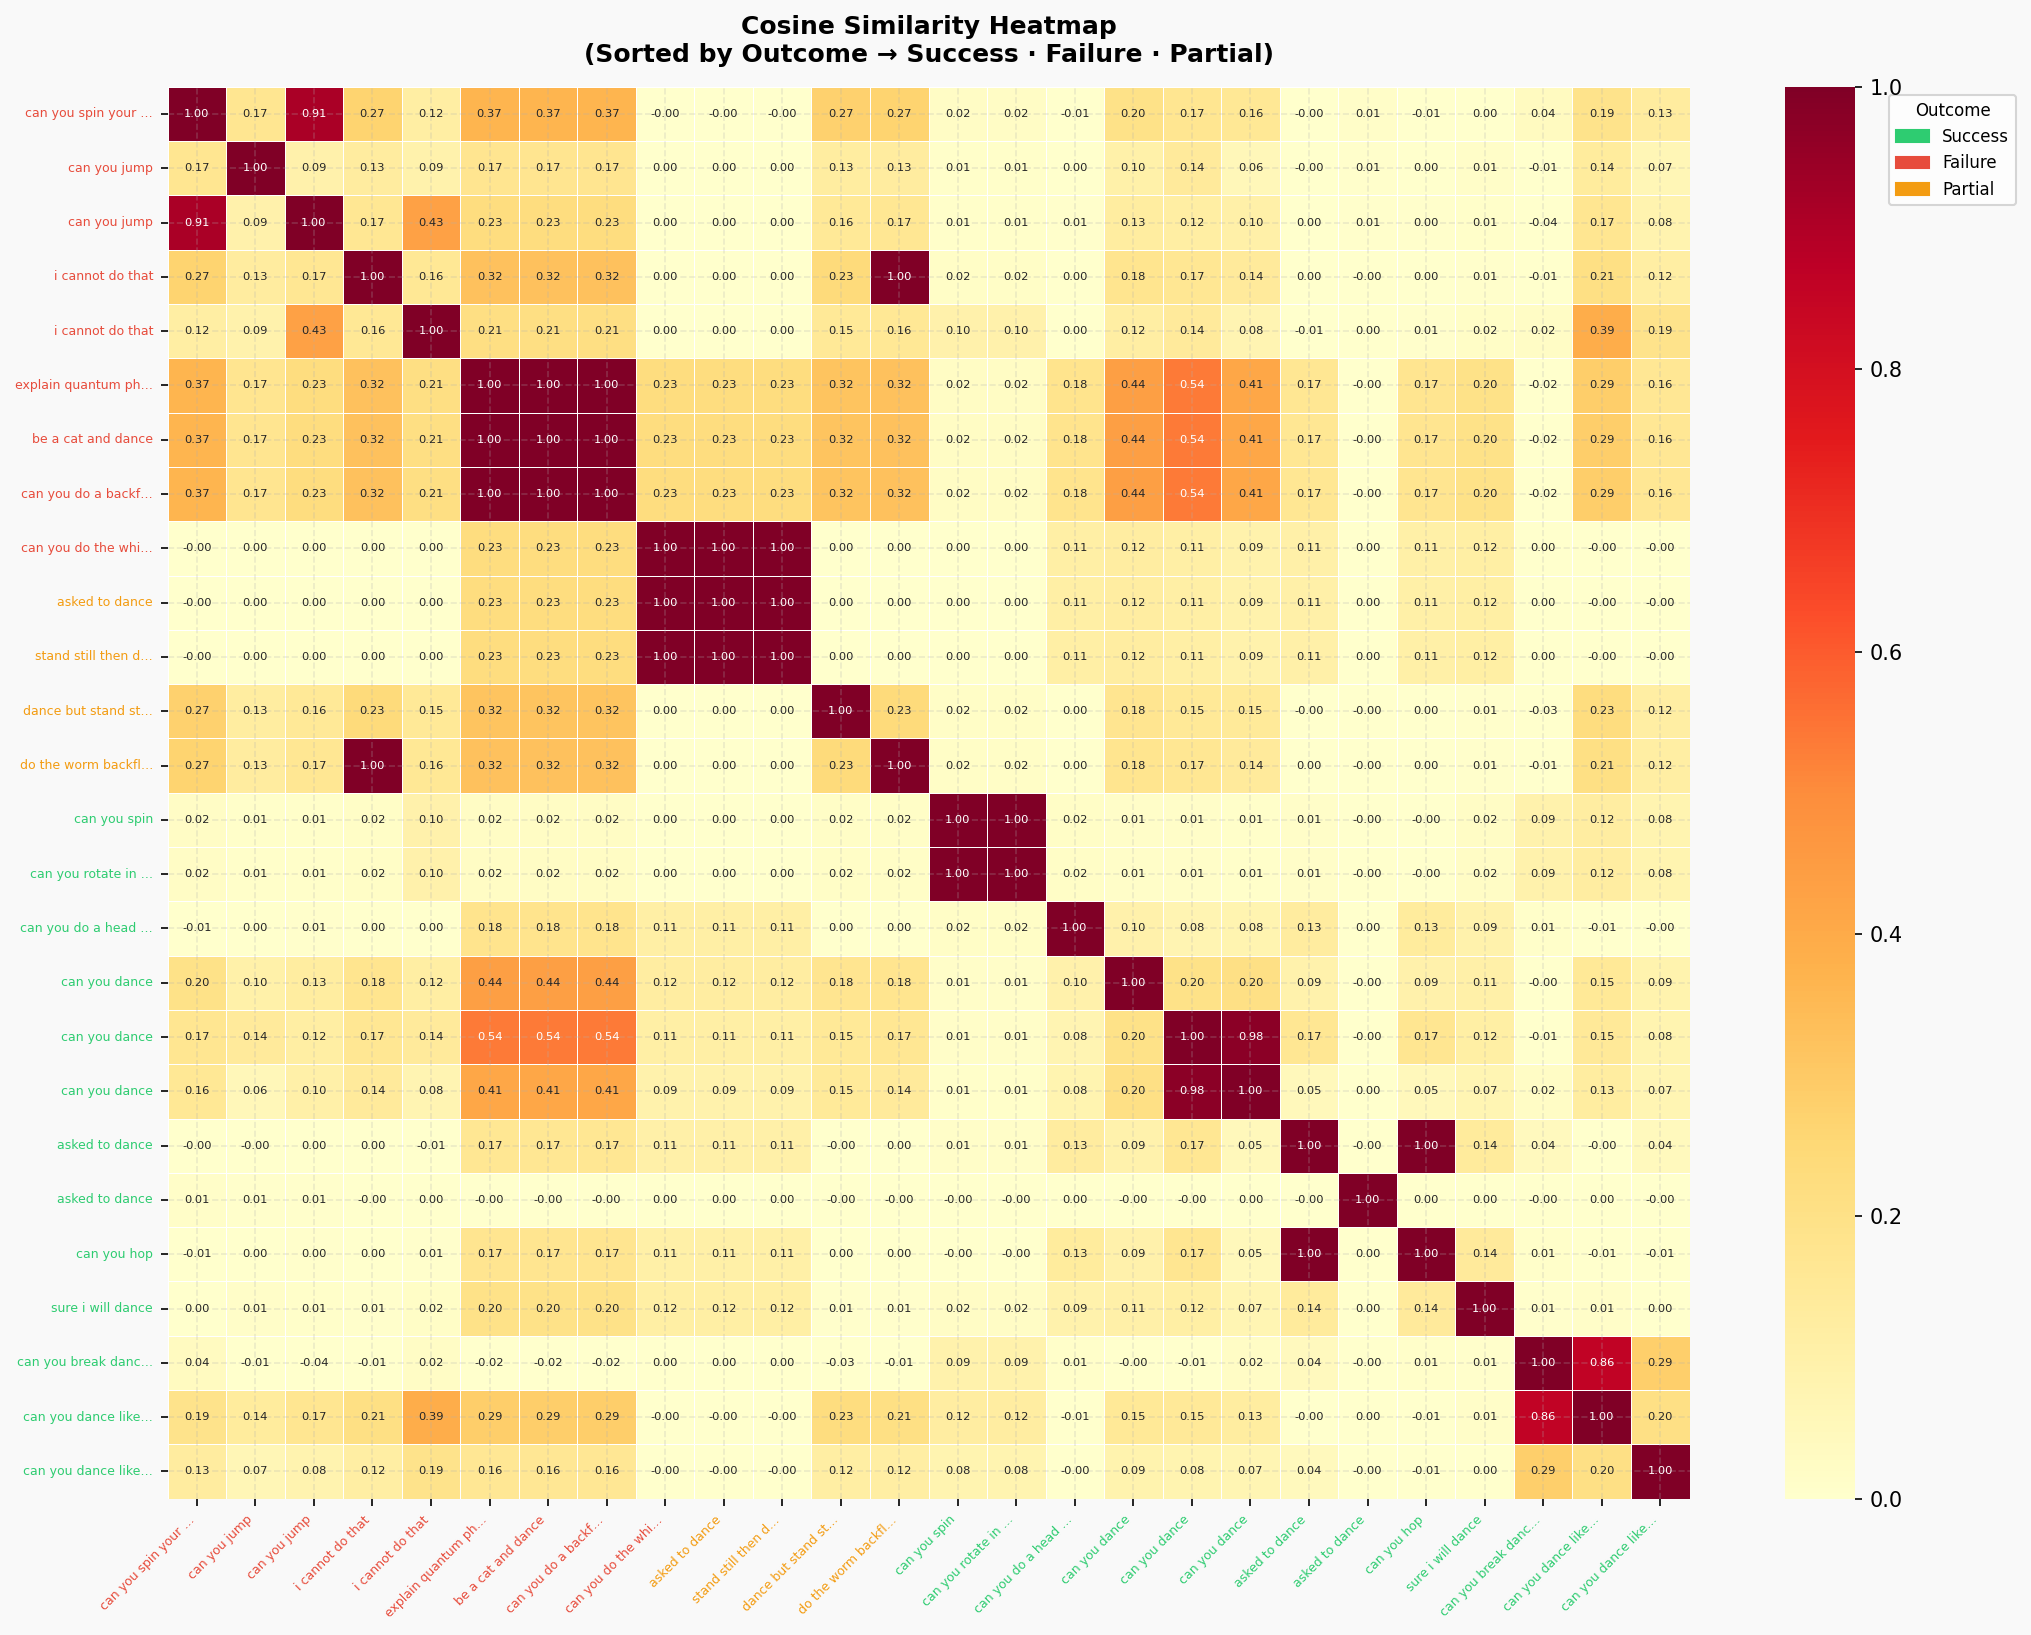

Saved → ./fig3_cosine_heatmap.png


In [8]:
df_sorted      = df.sort_values(by=['outcome', 'exp_round']).reset_index(drop=True)
cos_sim_sorted = cosine_similarity(X_lsa[df_sorted.index])
tick_labels    = [f"{r['prompt'][:18]}…" if len(r['prompt']) > 18 else r['prompt']
                  for _, r in df_sorted.iterrows()]
outcome_colors = [PALETTE[o] for o in df_sorted['outcome']]

fig, ax = plt.subplots(figsize=(14, 11), facecolor='#f9f9f9')
sns.heatmap(cos_sim_sorted, ax=ax,
            xticklabels=tick_labels, yticklabels=tick_labels,
            cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.4, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 5.5})

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
for tick, c in zip(ax.get_yticklabels(), outcome_colors): tick.set_color(c)
for tick, c in zip(ax.get_xticklabels(), outcome_colors): tick.set_color(c)

patches = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in PALETTE.items()]
ax.legend(handles=patches, loc='upper right', fontsize=8, title='Outcome',
          title_fontsize=8, bbox_to_anchor=(1.22, 1.0))
ax.set_title('Cosine Similarity Heatmap\n(Sorted by Outcome → Success · Failure · Partial)',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
path3 = f'{SAVE_DIR}/fig3_cosine_heatmap.png'
plt.savefig(path3, dpi=300, bbox_inches='tight', facecolor='#f9f9f9')
plt.show()
print(f'Saved → {path3}')

## Centroid Distance Map & Within/Between-Cluster Similarity

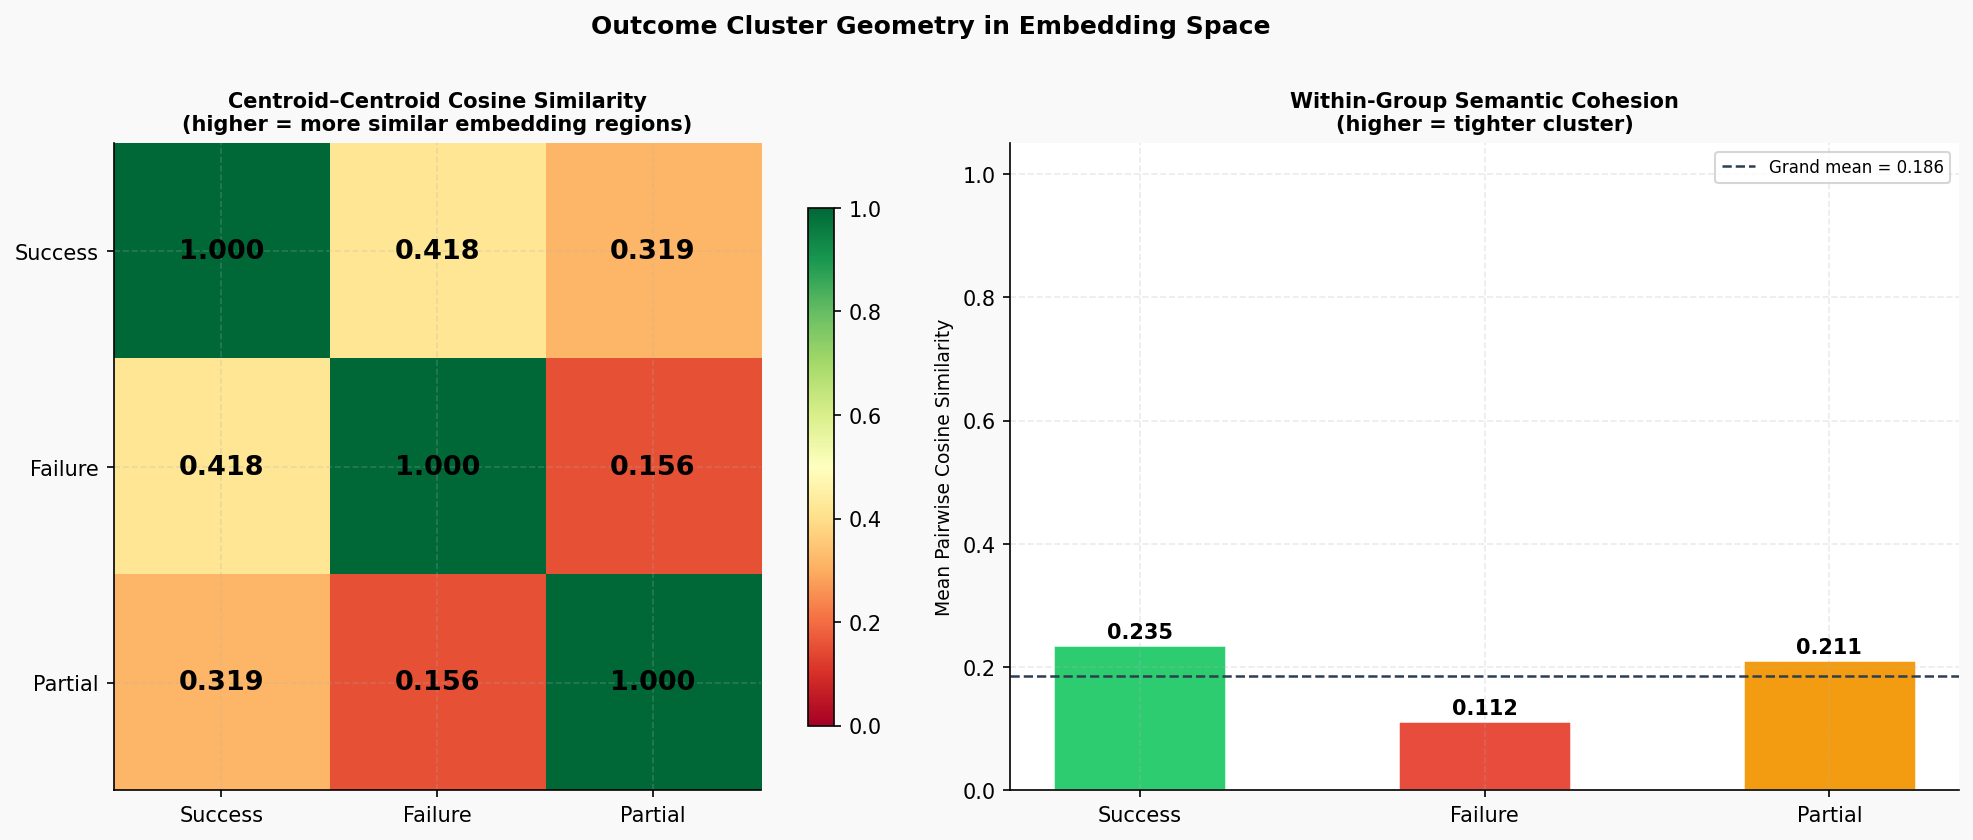

Saved → ./fig4_centroid_similarity.png


In [9]:
outcomes  = ['success', 'failure', 'partial']
centroids = {o: X_lsa[df['outcome'] == o].mean(axis=0) for o in outcomes}
C_mat     = np.vstack([centroids[o] for o in outcomes])
cent_sim  = cosine_similarity(C_mat)

within_sim = {}
for o in outcomes:
    idx  = df[df['outcome'] == o].index
    embs = X_lsa[idx]
    if len(embs) < 2:
        within_sim[o] = 1.0
    else:
        sims = cosine_similarity(embs)
        np.fill_diagonal(sims, np.nan)
        within_sim[o] = np.nanmean(sims)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='#f9f9f9')

# Left: centroid cosine matrix
labels = [o.capitalize() for o in outcomes]
im = axes[0].imshow(cent_sim, cmap='RdYlGn', vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{cent_sim[i,j]:.3f}',
                     ha='center', va='center', fontsize=13,
                     fontweight='bold', color='black')
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(labels, fontsize=10)
plt.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_title('Centroid–Centroid Cosine Similarity\n(higher = more similar embedding regions)',
                   fontsize=10, fontweight='bold')

# Right: within-group cohesion
vals  = [within_sim[o] for o in outcomes]
bars  = axes[1].bar(labels, vals, color=[PALETTE[o] for o in outcomes],
                    edgecolor='white', linewidth=1.2, width=0.5)
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Mean Pairwise Cosine Similarity', fontsize=9)
axes[1].set_title('Within-Group Semantic Cohesion\n(higher = tighter cluster)',
                   fontsize=10, fontweight='bold')
axes[1].axhline(np.mean(vals), color='#2c3e50', lw=1.2, linestyle='--',
                label=f'Grand mean = {np.mean(vals):.3f}')
axes[1].legend(fontsize=8)

fig.suptitle('Outcome Cluster Geometry in Embedding Space',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
path4 = f'{SAVE_DIR}/fig4_centroid_similarity.png'
plt.savefig(path4, dpi=300, bbox_inches='tight', facecolor='#f9f9f9')
plt.show()
print(f'Saved → {path4}')

## Round-Wise Progression in PCA Space

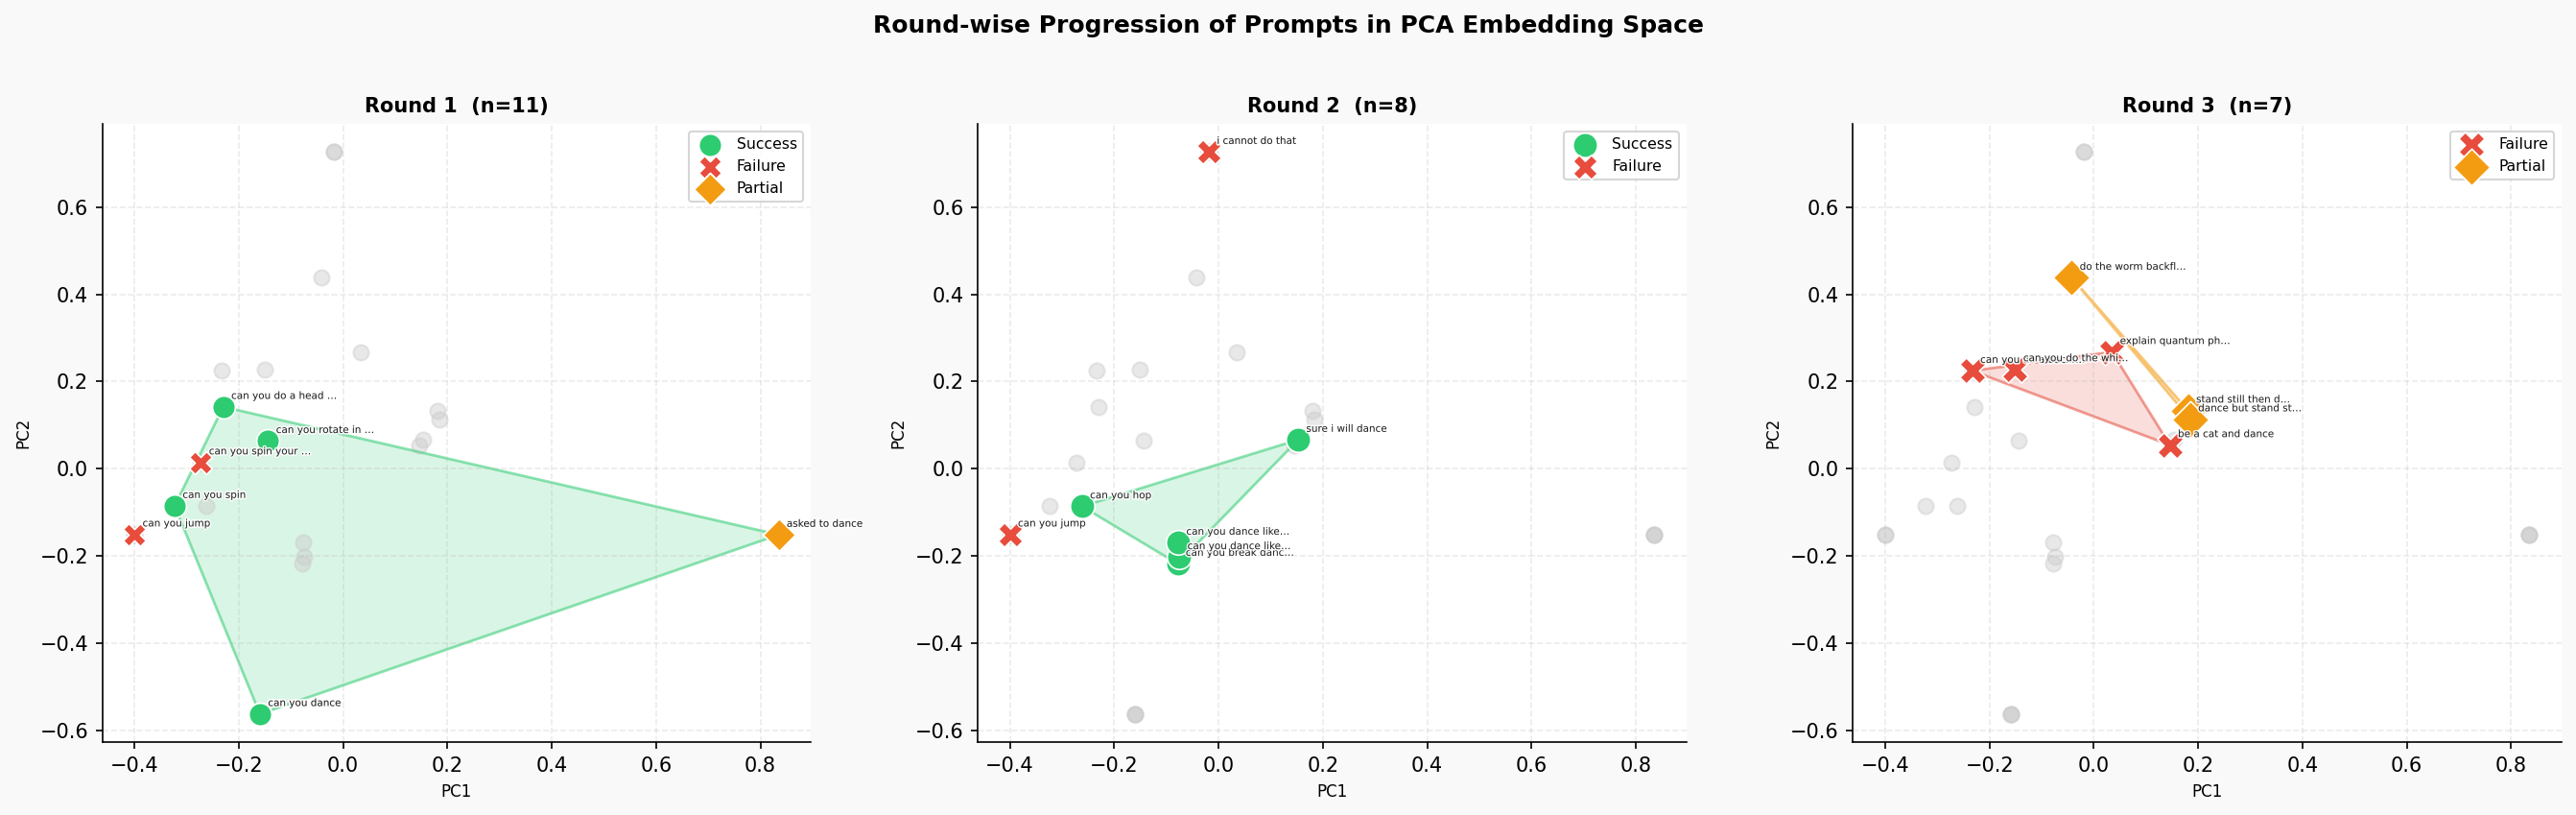

Saved → ./fig5_round_progression.png


In [10]:
round_sizes_d = {1: 130, 2: 150, 3: 170}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='#f9f9f9')

for ax, rnd in zip(axes, [1, 2, 3]):
    sub_rnd = df[df['exp_round'] == rnd]
    # All points as grey background
    ax.scatter(df['pca_x'], df['pca_y'], c='#cccccc', s=60, zorder=1, alpha=0.45)
    # Current round coloured by outcome
    for outcome in ['success', 'failure', 'partial']:
        sub = sub_rnd[sub_rnd['outcome'] == outcome]
        if sub.empty:
            continue
        ax.scatter(sub['pca_x'], sub['pca_y'],
                   c=PALETTE[outcome], marker=MARKERS[outcome],
                   s=round_sizes_d[rnd], edgecolors='white', linewidths=0.8,
                   label=outcome.capitalize(), zorder=3)
        draw_convex_hull(ax, sub['pca_x'], sub['pca_y'], PALETTE[outcome], alpha=0.18)
    for _, row in sub_rnd.iterrows():
        lbl = row['prompt'][:18] + ('…' if len(row['prompt']) > 18 else '')
        ax.annotate(lbl, xy=(row['pca_x'], row['pca_y']),
                    xytext=(4, 4), textcoords='offset points', fontsize=5, alpha=0.85,
                    path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])
    ax.set_title(f'Round {rnd}  (n={len(sub_rnd)})', fontsize=10, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=8); ax.set_ylabel('PC2', fontsize=8)
    ax.legend(fontsize=7.5, framealpha=0.8)

fig.suptitle('Round-wise Progression of Prompts in PCA Embedding Space',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
path5 = f'{SAVE_DIR}/fig5_round_progression.png'
plt.savefig(path5, dpi=300, bbox_inches='tight', facecolor='#f9f9f9')
plt.show()
print(f'Saved → {path5}')

## t-SNE with KDE Density Contours

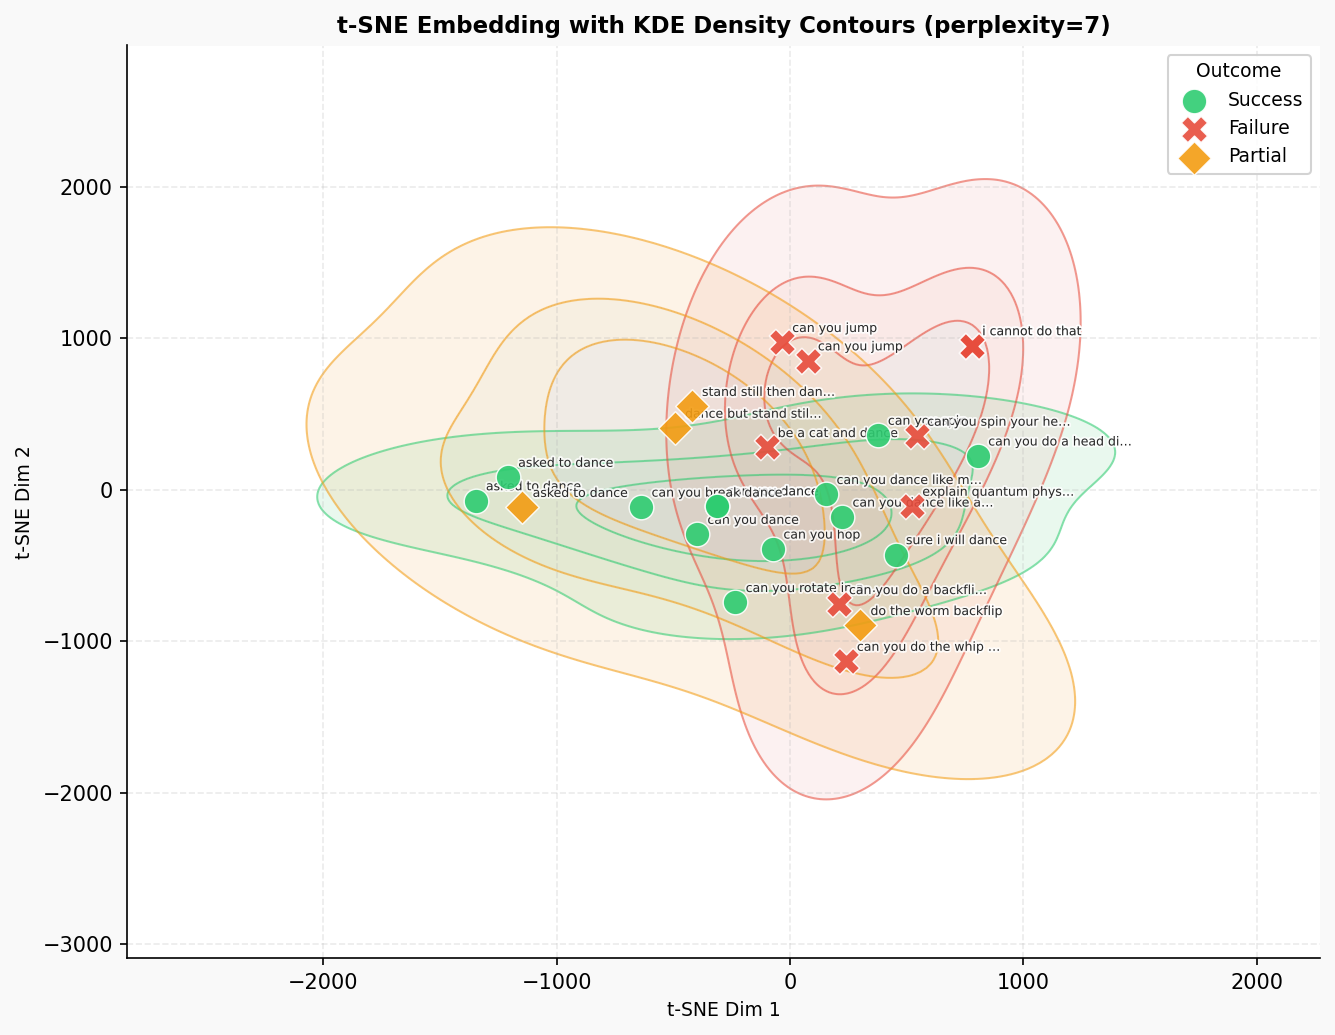

Saved → ./fig6_tsne_kde.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 7), facecolor='#f9f9f9')

for outcome in ['success', 'failure', 'partial']:
    sub = df[df['outcome'] == outcome]
    if len(sub) >= 3:
        try:
            sns.kdeplot(x=sub['tsne_x'], y=sub['tsne_y'], ax=ax,
                        color=PALETTE[outcome], fill=True, alpha=0.12,
                        bw_adjust=1.2, levels=4, thresh=0.1, zorder=0)
            sns.kdeplot(x=sub['tsne_x'], y=sub['tsne_y'], ax=ax,
                        color=PALETTE[outcome], fill=False, alpha=0.55,
                        bw_adjust=1.2, levels=4, thresh=0.1, linewidths=1, zorder=1)
        except Exception:
            pass

for outcome in ['success', 'failure', 'partial']:
    sub = df[df['outcome'] == outcome]
    ax.scatter(sub['tsne_x'], sub['tsne_y'],
               c=PALETTE[outcome], marker=MARKERS[outcome],
               s=SIZES[outcome], edgecolors='white', linewidths=0.7,
               label=outcome.capitalize(), zorder=4, alpha=0.9)

for _, row in df.iterrows():
    lbl = row['prompt'][:20] + ('…' if len(row['prompt']) > 20 else '')
    ax.annotate(lbl, xy=(row['tsne_x'], row['tsne_y']),
                xytext=(5, 5), textcoords='offset points', fontsize=6, alpha=0.8,
                path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])

ax.set_title(f't-SNE Embedding with KDE Density Contours (perplexity={perp})',
             fontsize=11, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1', fontsize=9); ax.set_ylabel('t-SNE Dim 2', fontsize=9)
ax.legend(fontsize=9, framealpha=0.85, title='Outcome', title_fontsize=9)

plt.tight_layout()
path6 = f'{SAVE_DIR}/fig6_tsne_kde.png'
plt.savefig(path6, dpi=300, bbox_inches='tight', facecolor='#f9f9f9')
plt.show()
print(f'Saved → {path6}')

## Top TF-IDF Terms per Outcome

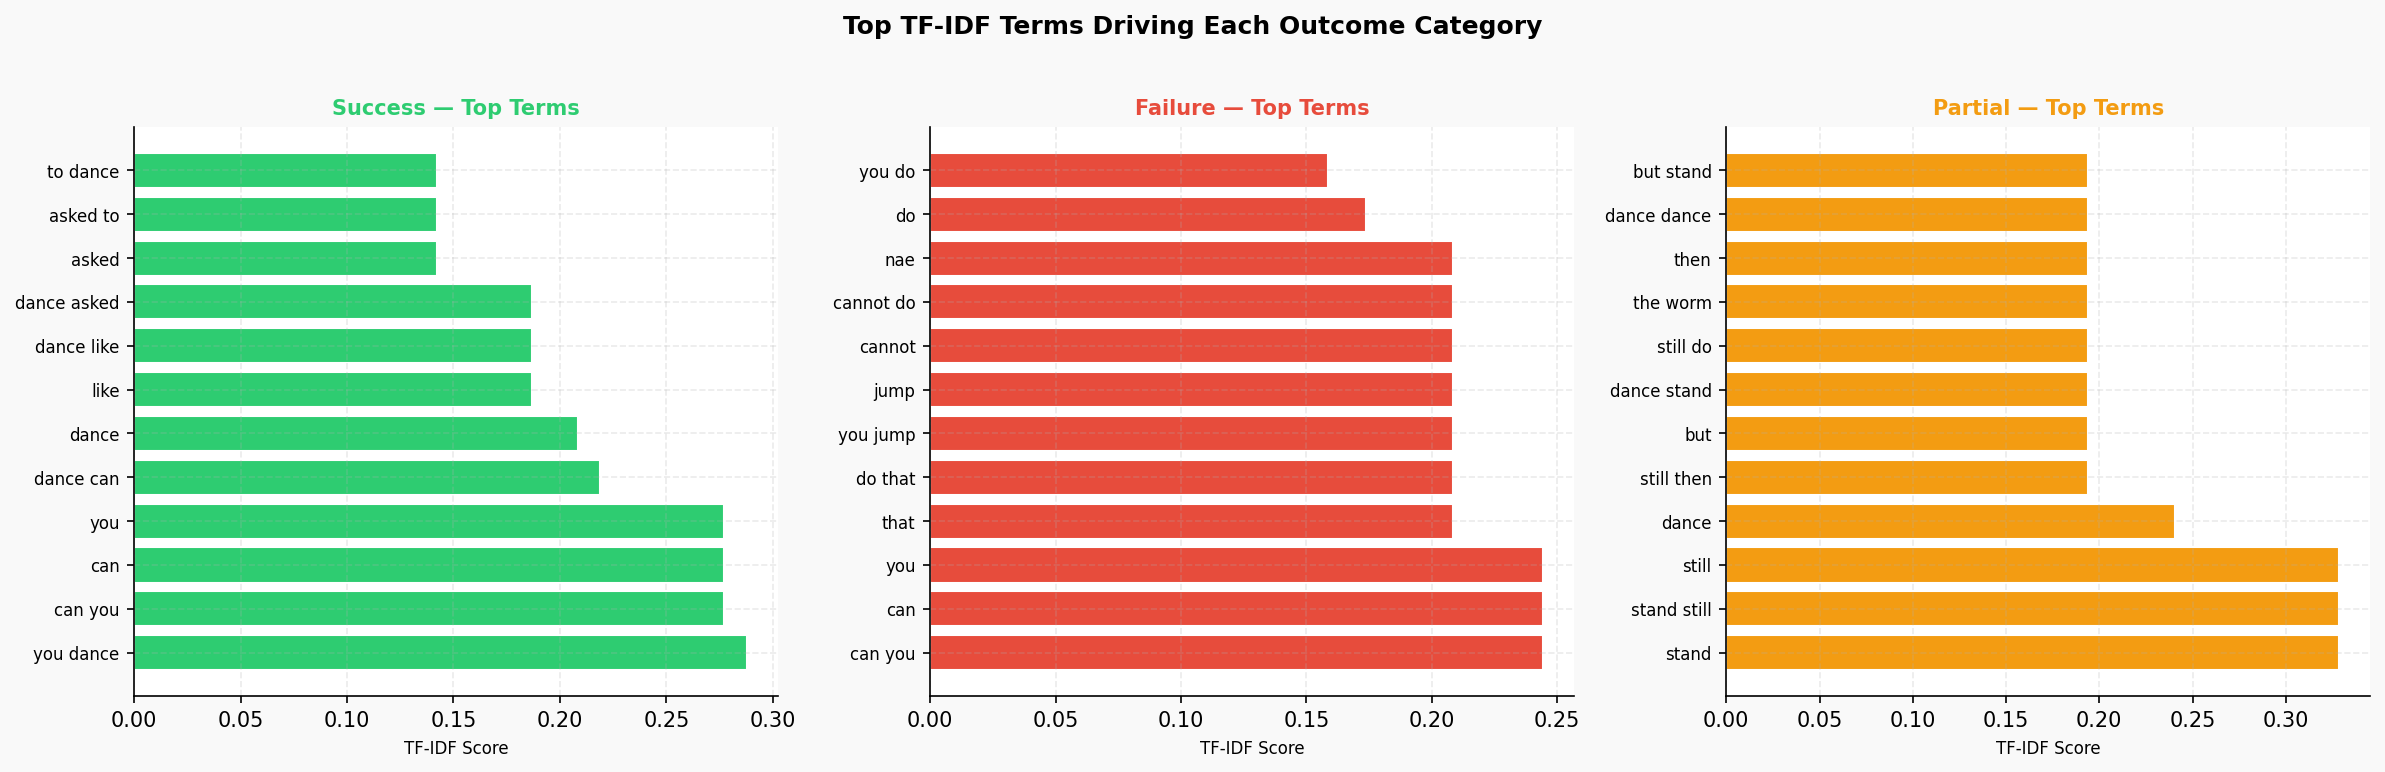

Saved → ./fig7_tfidf_terms.png


In [12]:
tfidf_interp = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                               min_df=1, sublinear_tf=True)
outcome_docs = {o: ' '.join(df.loc[df['outcome'] == o, 'prompt'])
                for o in ['success', 'failure', 'partial']}
X_int = tfidf_interp.fit_transform(list(outcome_docs.values()))
feat  = tfidf_interp.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#f9f9f9')

for ax, (outcome, doc_idx) in zip(axes, zip(['success', 'failure', 'partial'], [0, 1, 2])):
    scores  = X_int[doc_idx].toarray().ravel()
    top_idx = scores.argsort()[-12:][::-1]
    top_terms  = feat[top_idx]
    top_scores = scores[top_idx]

    ax.barh(range(12), top_scores[::-1], color=PALETTE[outcome], edgecolor='white')
    ax.set_yticks(range(12))
    ax.set_yticklabels(top_terms[::-1], fontsize=8)
    ax.set_xlabel('TF-IDF Score', fontsize=8)
    ax.set_title(f'{outcome.capitalize()} — Top Terms',
                 fontsize=10, fontweight='bold', color=PALETTE[outcome])
    ax.invert_yaxis()

fig.suptitle('Top TF-IDF Terms Driving Each Outcome Category',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
path7 = f'{SAVE_DIR}/fig7_tfidf_terms.png'
plt.savefig(path7, dpi=300, bbox_inches='tight', facecolor='#f9f9f9')
plt.show()
print(f'Saved → {path7}')

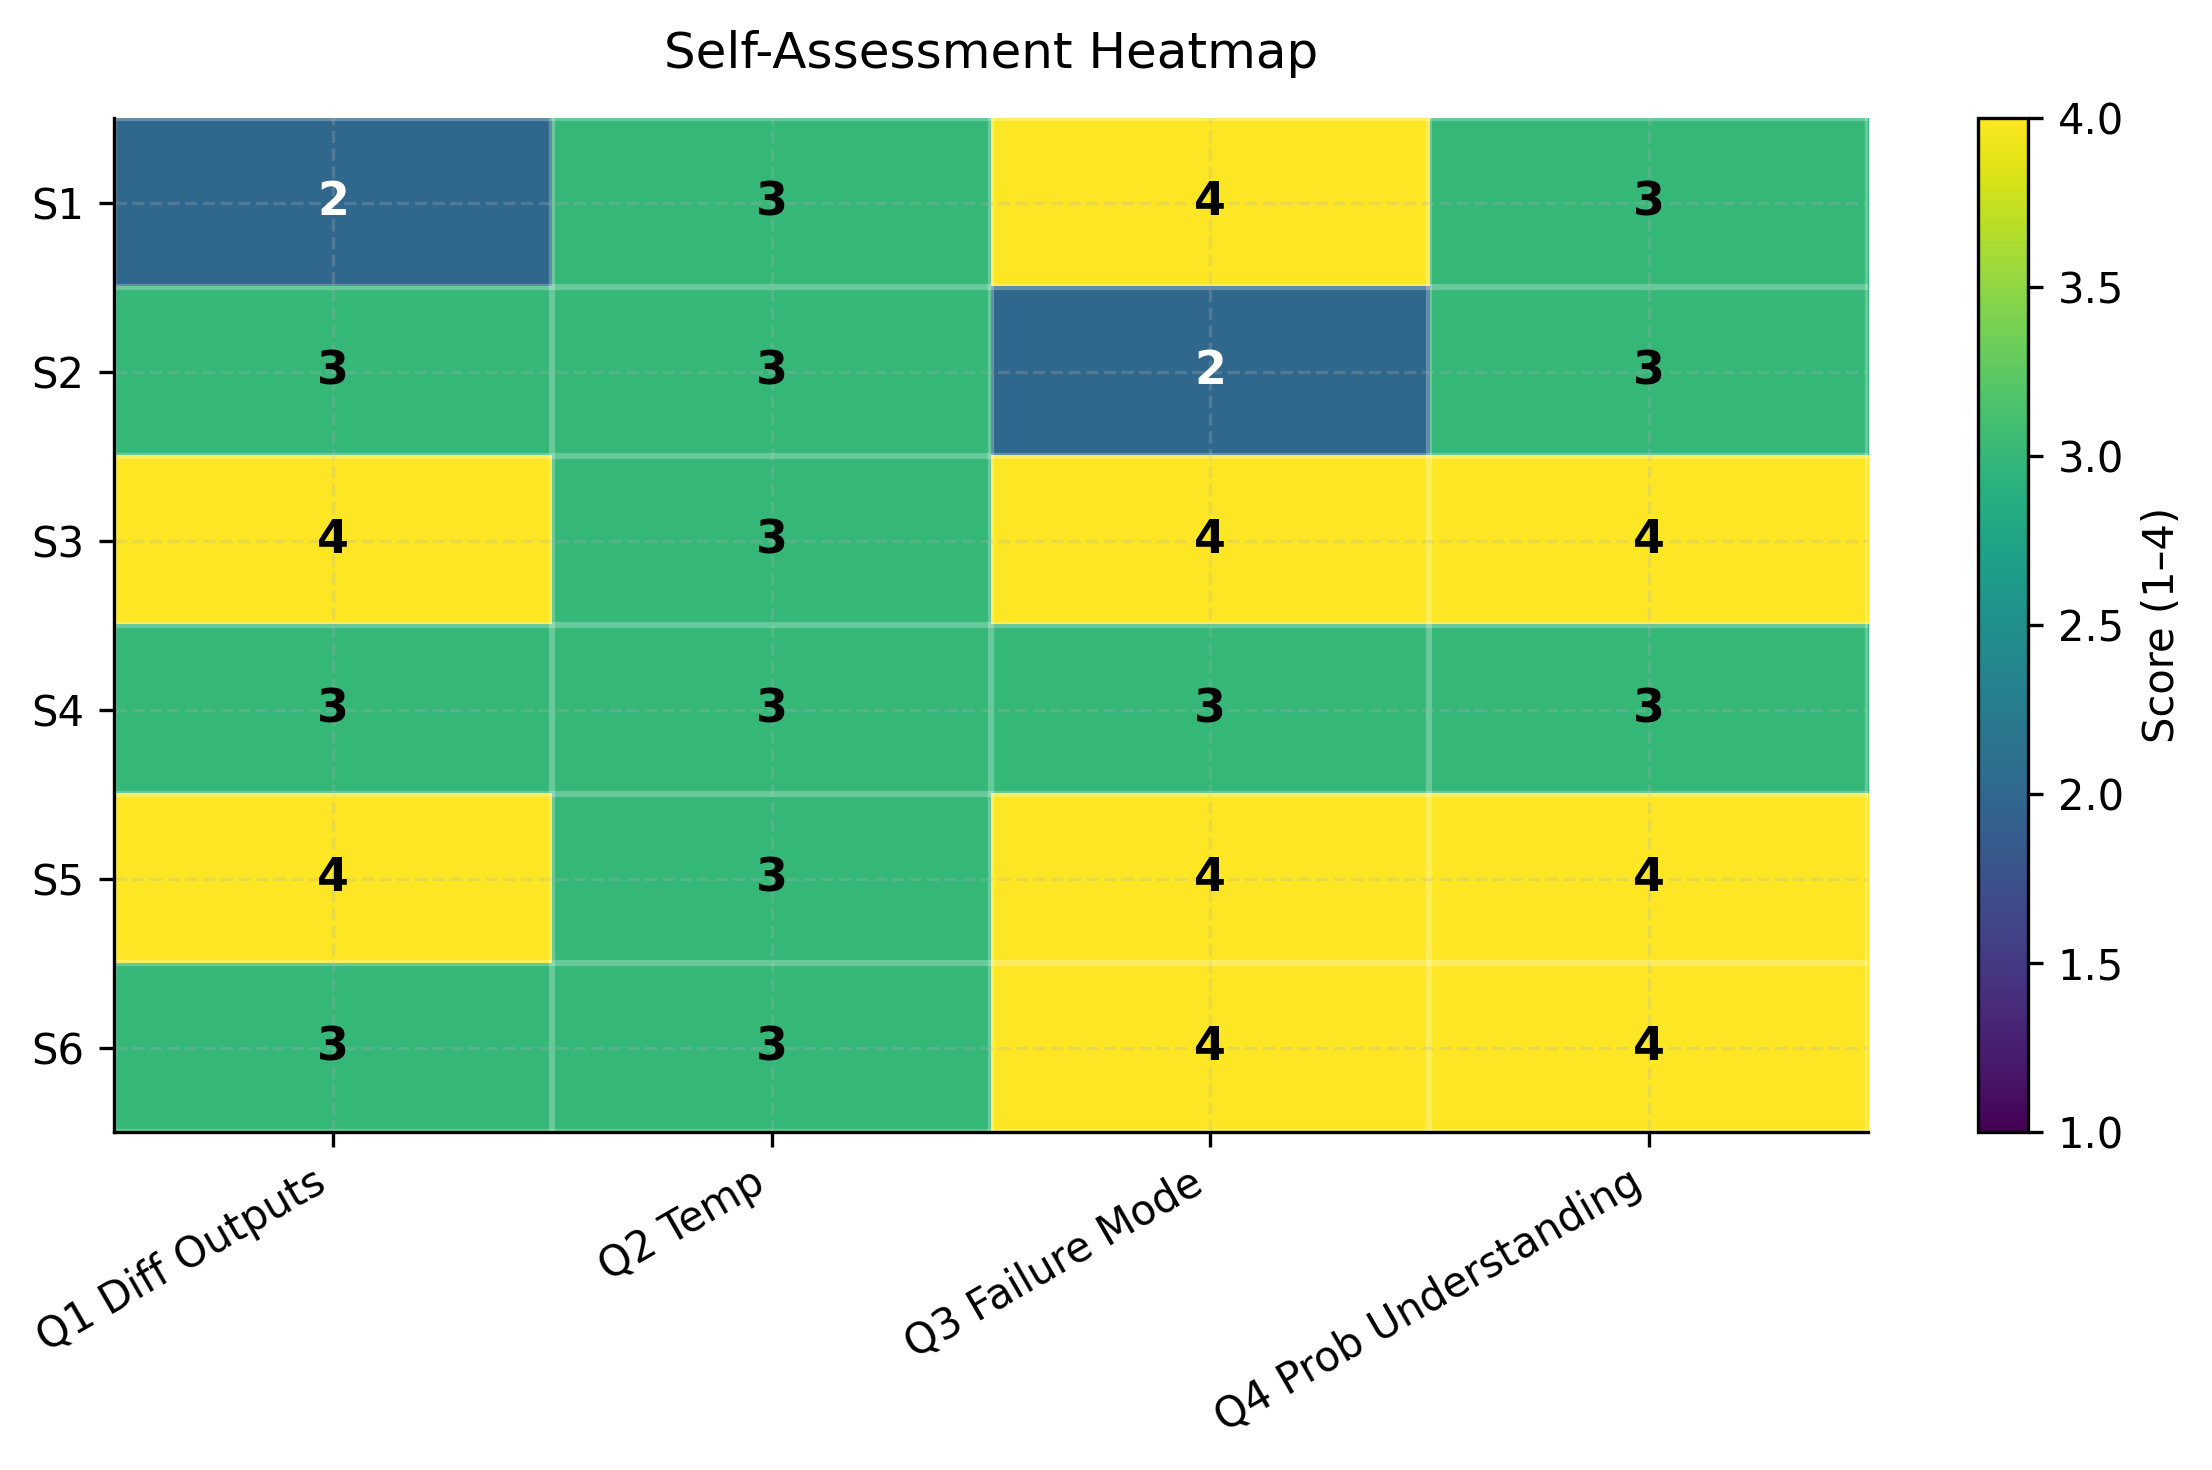

In [ ]:
# -----------------------------
# Data: corrected scores
# -----------------------------
scores = np.array([
    [2, 3, 4, 3],  # S1
    [3, 3, 2, 3],  # S2
    [4, 3, 4, 4],  # S3
    [3, 3, 3, 3],  # S4
    [4, 3, 4, 4],  # S5
    [3, 3, 4, 4]   # S6
])

students = ["S1", "S2", "S3", "S4", "S5", "S6"]
questions = [
    "Q1 Diff Outputs",
    "Q2 Temp",
    "Q3 Failure Mode",
    "Q4 Prob Understanding"
]

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Heatmap
im = ax.imshow(scores, aspect="auto", vmin=1, vmax=4)

# Axis ticks and labels
ax.set_xticks(np.arange(len(questions)))
ax.set_yticks(np.arange(len(students)))
ax.set_xticklabels(questions, rotation=30, ha="right")
ax.set_yticklabels(students)

# Title
ax.set_title("Self-Assessment Heatmap", pad=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Score (1–4)")

# -----------------------------
# Annotate each cell
# Use white text for darker cells, black for lighter cells
# -----------------------------
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        value = scores[i, j]
        text_color = "white" if value <= 2 else "black"
        ax.text(
            j, i, str(value),
            ha="center", va="center",
            color=text_color,
            fontsize=11,
            fontweight="bold"
        )

# -----------------------------
# Add gridlines between cells
# -----------------------------
ax.set_xticks(np.arange(-0.5, scores.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, scores.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()

# Save at 300 dpi
plt.savefig("self_assessment_heatmap_corrected.png", dpi=300, bbox_inches="tight")
plt.show()